In [ ]:
%pip install pretty_midi torch numpy


In [1]:
import torch
import numpy as np
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

GENERATED_DIR = PROJECT_ROOT / "generated"
GENERATED_DIR.mkdir(exist_ok=True)

from utils import (
    build_id_to_token,
    build_token_to_id,
    generate_and_play_for_temperatures,
    generate_tokens,
)
from model import load_trained_model

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "full_sequences.npz"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "music_gru_checkpoint.pt"


## 1. Load Trained Model Checkpoint
Load the trained GRU model and all metadata needed for generation.

In [2]:
# Device selection
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU.")
else:
    device = torch.device("cpu")
    print("Using CPU.")

print("Using device:", device)

# Load trained model
model, SEQ_LEN = load_trained_model(CHECKPOINT_PATH, device)
print("Loaded model from:", CHECKPOINT_PATH)

# Load processed dataset
data = np.load(DATA_PATH, allow_pickle=True)
X_ids = data["X"]
vocab = data["vocab"]  # saved vocab array

print("Loaded data from:", DATA_PATH)
print("  X_ids shape:", X_ids.shape)
print("  vocab shape:", vocab.shape)

Using Apple Silicon GPU (MPS).
Using device: mps
Loaded model from: /Users/catherinembata/music-generation-project/models/music_gru_checkpoint.pt
Loaded data from: /Users/catherinembata/music-generation-project/data/processed/full_sequences.npz
  X_ids shape: (773541, 50)
  vocab shape: (307, 2)


## 2. Rebuild Vocabulary and Duration Mapping
Reconstruct (pitch, duration_bucket) token mappings for converting predictions back to notes.

In [4]:
# vocab is an array of [pitch, bucket] pairs, shape (vocab_size, 2)
id_to_token = build_id_to_token(vocab)
token_to_id = build_token_to_id(id_to_token)


## 3. Generated Samples
Generate melodies at multiple temperatures and play the resulting music.

In [ ]:
results = generate_and_play_for_temperatures(
    model,
    X_ids,
    id_to_token=id_to_token,
    seq_len=SEQ_LEN,
    temps=(0.6, 0.8, 1.0),
    num_tokens=200,
    device=device,
    generated_dir=GENERATED_DIR,
)

results

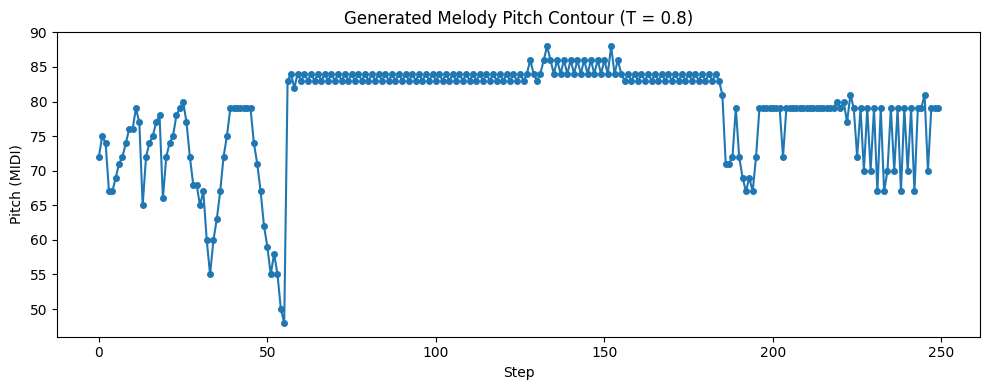

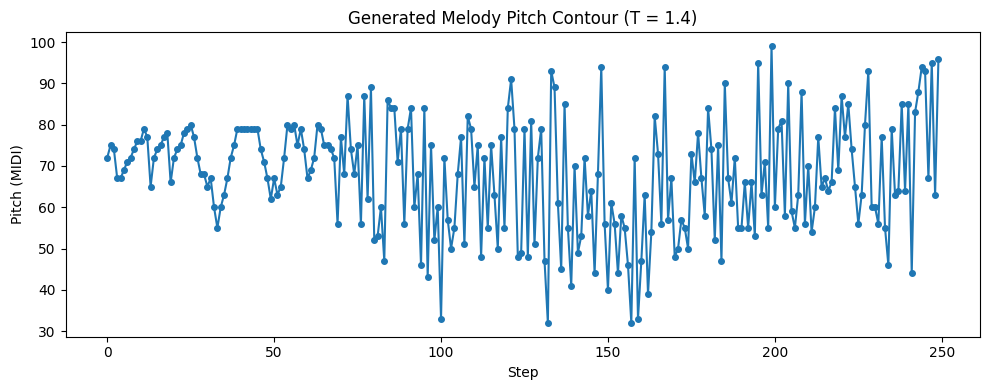

In [21]:
seed_seq = X_ids[0] 

temps_to_plot = [0.8, 1.4]

generated_sequences = {}

for temp in temps_to_plot:
    gen_ids = generate_tokens(
        model,
        seed_seq,
        seq_len=SEQ_LEN,
        num_tokens=200,
        temperature=temp,
        device=device
    )
    generated_sequences[temp] = gen_ids

def tokens_to_pitches(tokens, id_to_token):
    return [id_to_token[t][0] for t in tokens]

import matplotlib.pyplot as plt

def plot_pitch_contour(pitches, temp):
    plt.figure(figsize=(10, 4))
    plt.plot(pitches, marker='o', markersize=4)
    plt.title(f"Generated Melody Pitch Contour (T = {temp})")
    plt.xlabel("Step")
    plt.ylabel("Pitch (MIDI)")
    plt.tight_layout()
    plt.show()

for temp in temps_to_plot:
    pitches = tokens_to_pitches(generated_sequences[temp], id_to_token)
    save_path = f"images/pitch_T{str(temp).replace('.', '')}.png"
    plot_pitch_contour(pitches, temp)

## Edge Case Analysis

To evaluate how the model responds to different types of inputs, I generated sequences from four seed configurations: a repeated-note seed, a short consisting of one token, and a random seed.

In [ ]:
import numpy as np

# -----------------------------------------------------
# 1) Repeated-note seed
# -----------------------------------------------------
seed_repeated = np.array([60] * 16)

generated_repeated = generate_tokens(
    model,
    seed_seq=seed_repeated,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

# -----------------------------------------------------
# 2) Single-token seed
# -----------------------------------------------------
seed_short1 = np.array([60])

generated_short1 = generate_tokens(
    model,
    seed_seq=seed_short1,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

# -----------------------------------------------------
# 3) Random seed
# -----------------------------------------------------
VOCAB_SIZE = vocab.shape[0]
np.random.seed(42)
random_seed = np.random.randint(0, VOCAB_SIZE, size=16)

generated_random = generate_tokens(
    model,
    seed_seq=random_seed,
    seq_len=SEQ_LEN,
    num_tokens=100,
    temperature=1.0,
    device=device
)

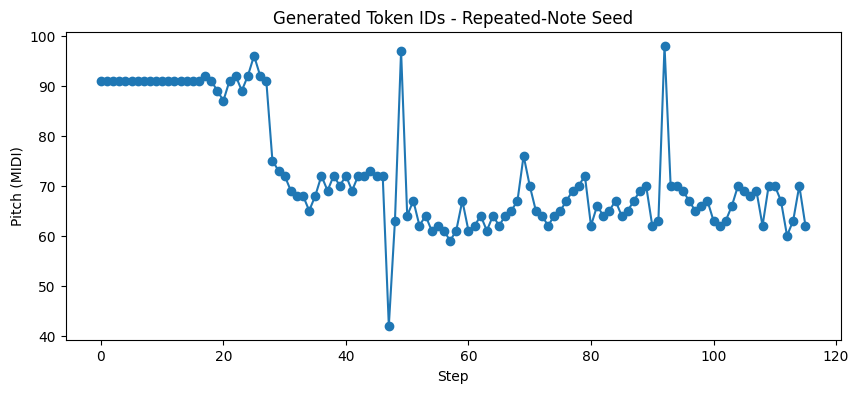

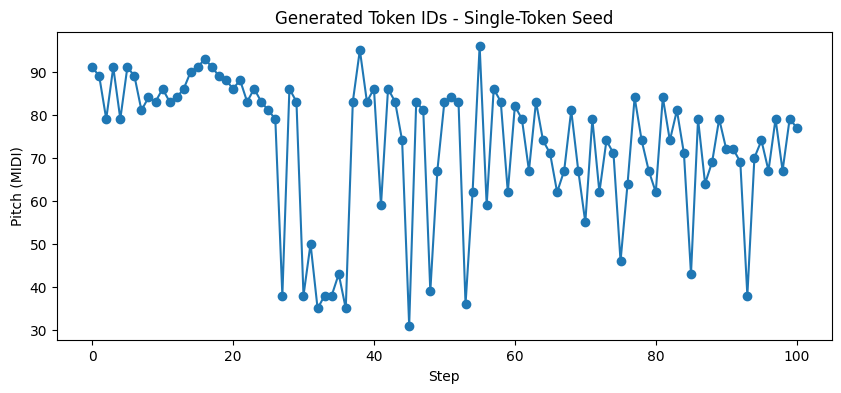

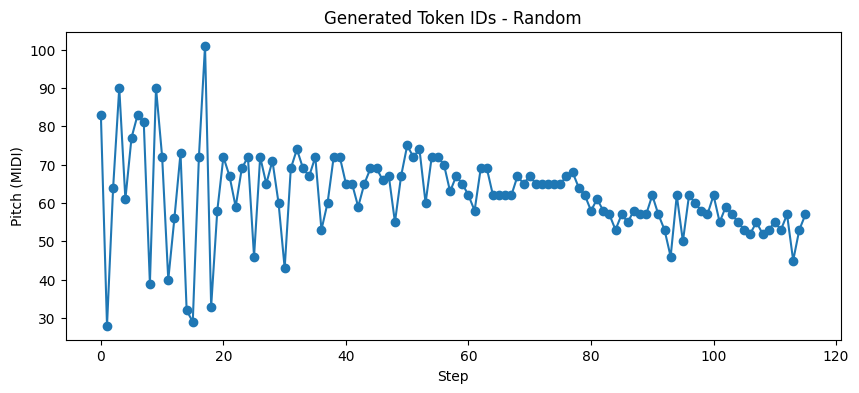

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_tokens(tokens, title):
    values = [id_to_token[t][0] for t in tokens]  # extract pitch
    plt.figure(figsize=(10, 4))
    plt.plot(values, marker='o')
    plt.title(title)
    plt.xlabel('Step')
    plt.ylabel("Pitch (MIDI)")
    plt.show()

# 1) Repeated seed
plot_tokens(generated_repeated, 'Generated Token IDs - Repeated-Note Seed')

# 2) Very short seed (1 token)
plot_tokens(generated_short1, 'Generated Token IDs - Single-Token Seed')

# 3) Stress seed (random)
plot_tokens(generated_random, 'Generated Token IDs - Random')

### Analysis

#### Repeated Note Seed: 
The model begins by repeating the seed pitch for several steps, created a flat countour (as expected). Once it moves past the initial seed context, the melody drops into a lower pitch range and remains mostly stable aside from a few spikes to very high ranges. This pattern suggests that when the seed provides too little melodic information, the model briefly stabilizes but eventually drifts unpredictably, producing occasional extreme notes before returning to a more constrained region.

#### Very Short Seeds (1-token):
The model starts in a pitch band close to the original note, but becomes highly erractic after ~25 steps, oscillating between very high and very low pitches. This reflects the model’s reliance on having a sufficient historical window. When given only one token, the GRU lacks the context it was trained on and generates a highly unstable trajectory as it tries to “guess” what kind of musical phrase should follow.

#### Random Seed:
The random seed produces the most unstable behavior at the beginning of the seed compared to the two other cases. The model has irregular swings from high to low pitches, suggesting that it has no structure to anchor itself to. After ~20–30 steps, the melody stabilizes into a middle register with relatively small intervals and fewer outliers. This indicates that although the seed is noisy, the GRU can recover by leaning on its own recent outputs, gradually overriding the poor starting context.

#### Overall Synthesis
Across the three experiments, the model demonstrates a clear dependence on seed structure and length:
-   A uniform, overly simple seed (repeated note) initially produces stability, but the model drifts and occasionally spikes to extreme pitches once it moves beyond what the seed can anchor.
-   A single-token seed gives the model too little information, resulting in the most consistently erratic melodic contour.
-   A random seed starts in disarray but stabilizes over time as the model gradually replaces the chaotic context with its own generated structure.
-   These patterns suggest that the GRU maintains stability only when it has access to a sufficiently rich and coherent context, either provided by the seed or created by the model itself after several steps. Improving long-range conditioning or incorporating positional/context cues could help reduce drift and stabilize outputs even when the initial seed is sparse or unstructured.

